In [ ]:
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

In [376]:
df = pd.read_csv('D:/documents and video random/documents/telco customer churn prediction/Telco-Customer-Churn.csv')
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [377]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [378]:
df = df.drop(['customerID'], axis=1)
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [379]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [380]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)
print(df.dtypes)

gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object


In [381]:
print(f"Total records: {len(df)}")
print("\nMissing values by column:")
print(df.isnull().sum())

Total records: 7043

Missing values by column:
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [382]:
df[df["TotalCharges"].isna()][["tenure", "MonthlyCharges", "TotalCharges"]]

,tenure,MonthlyCharges,TotalCharges
488,0,52.55,NaN
753,0,20.25,NaN
936,0,80.85,NaN
1082,0,25.75,NaN
1340,0,56.05,NaN
3331,0,19.85,NaN
3826,0,25.35,NaN
4380,0,20.00,NaN
5218,0,19.70,NaN
6670,0,73.35,NaN


In [383]:
df.loc[df["tenure"] == 0, "TotalCharges"] = 0
df["TotalCharges"].isna().sum()

0

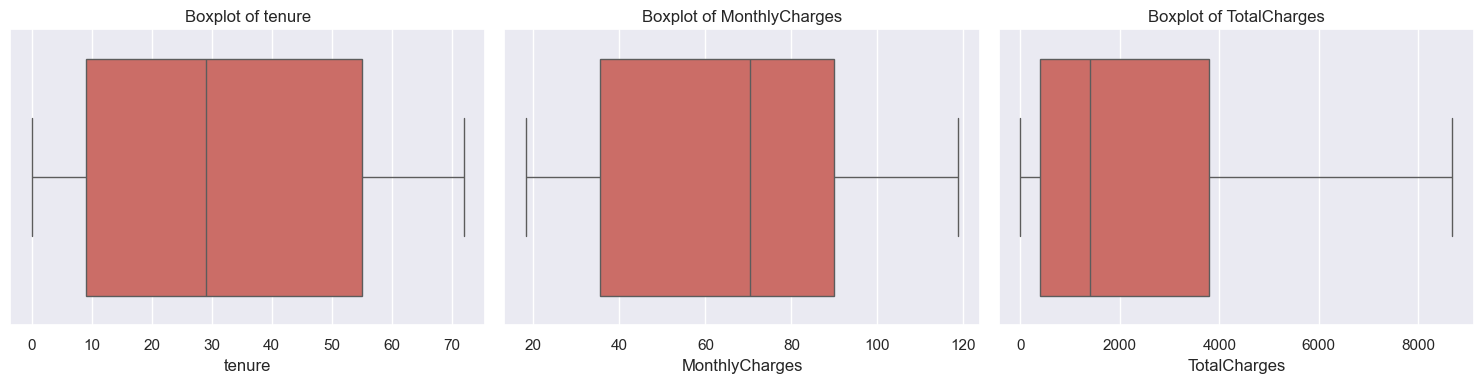

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = ["tenure", "MonthlyCharges",
                "TotalCharges"
                ]

fig, axes = plt.subplots(1, len(numeric_cols), figsize=(15, 4))

for i, col in enumerate(numeric_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()

In [385]:
numeric_cols = ["tenure","MonthlyCharges",
                "TotalCharges"
                ]
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col} : {len(outliers)} Outliers")

tenure : 0 Outliers
MonthlyCharges : 0 Outliers
TotalCharges : 0 Outliers


In [386]:
target = "Churn"

X = df.drop(columns=["Churn"])
y = df["Churn"]

categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()
continuous_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

categorical_features.append("SeniorCitizen")
continuous_features.remove("SeniorCitizen")

print('\nCategorical Features: ', categorical_features)
print('\nContinuous Features: ', continuous_features)



Categorical Features:  ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'SeniorCitizen']

Continuous Features:  ['tenure', 'MonthlyCharges', 'TotalCharges']


In [387]:
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder

%matplotlib inline
sns.set(style="darkgrid")
sns.set_palette("hls", 3)

Churn
No     5174
Yes    1869
dtype: int64


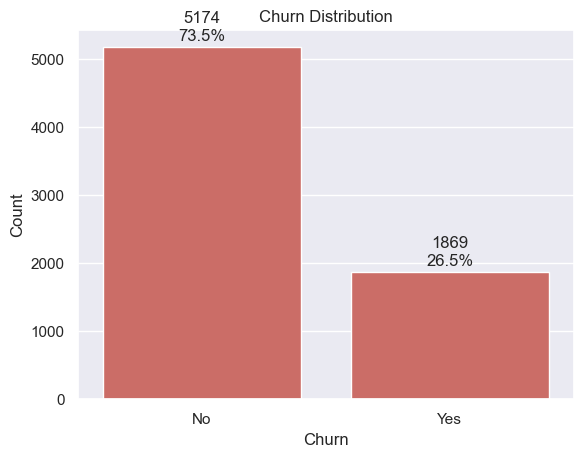

In [388]:
print(df.groupby(['Churn']).size())
ax = sns.countplot(
    data=df,
    x="Churn",
    order=df["Churn"].value_counts().index
)

total = len(df)

for container in ax.containers:
    labels = [f"{int(v.get_height())}\n{v.get_height()/total:.1%}" for v in container]
    ax.bar_label(container, labels=labels, padding=3)

ax.set_title("Churn Distribution")
ax.set_xlabel("Churn")
ax.set_ylabel("Count")
plt.show()

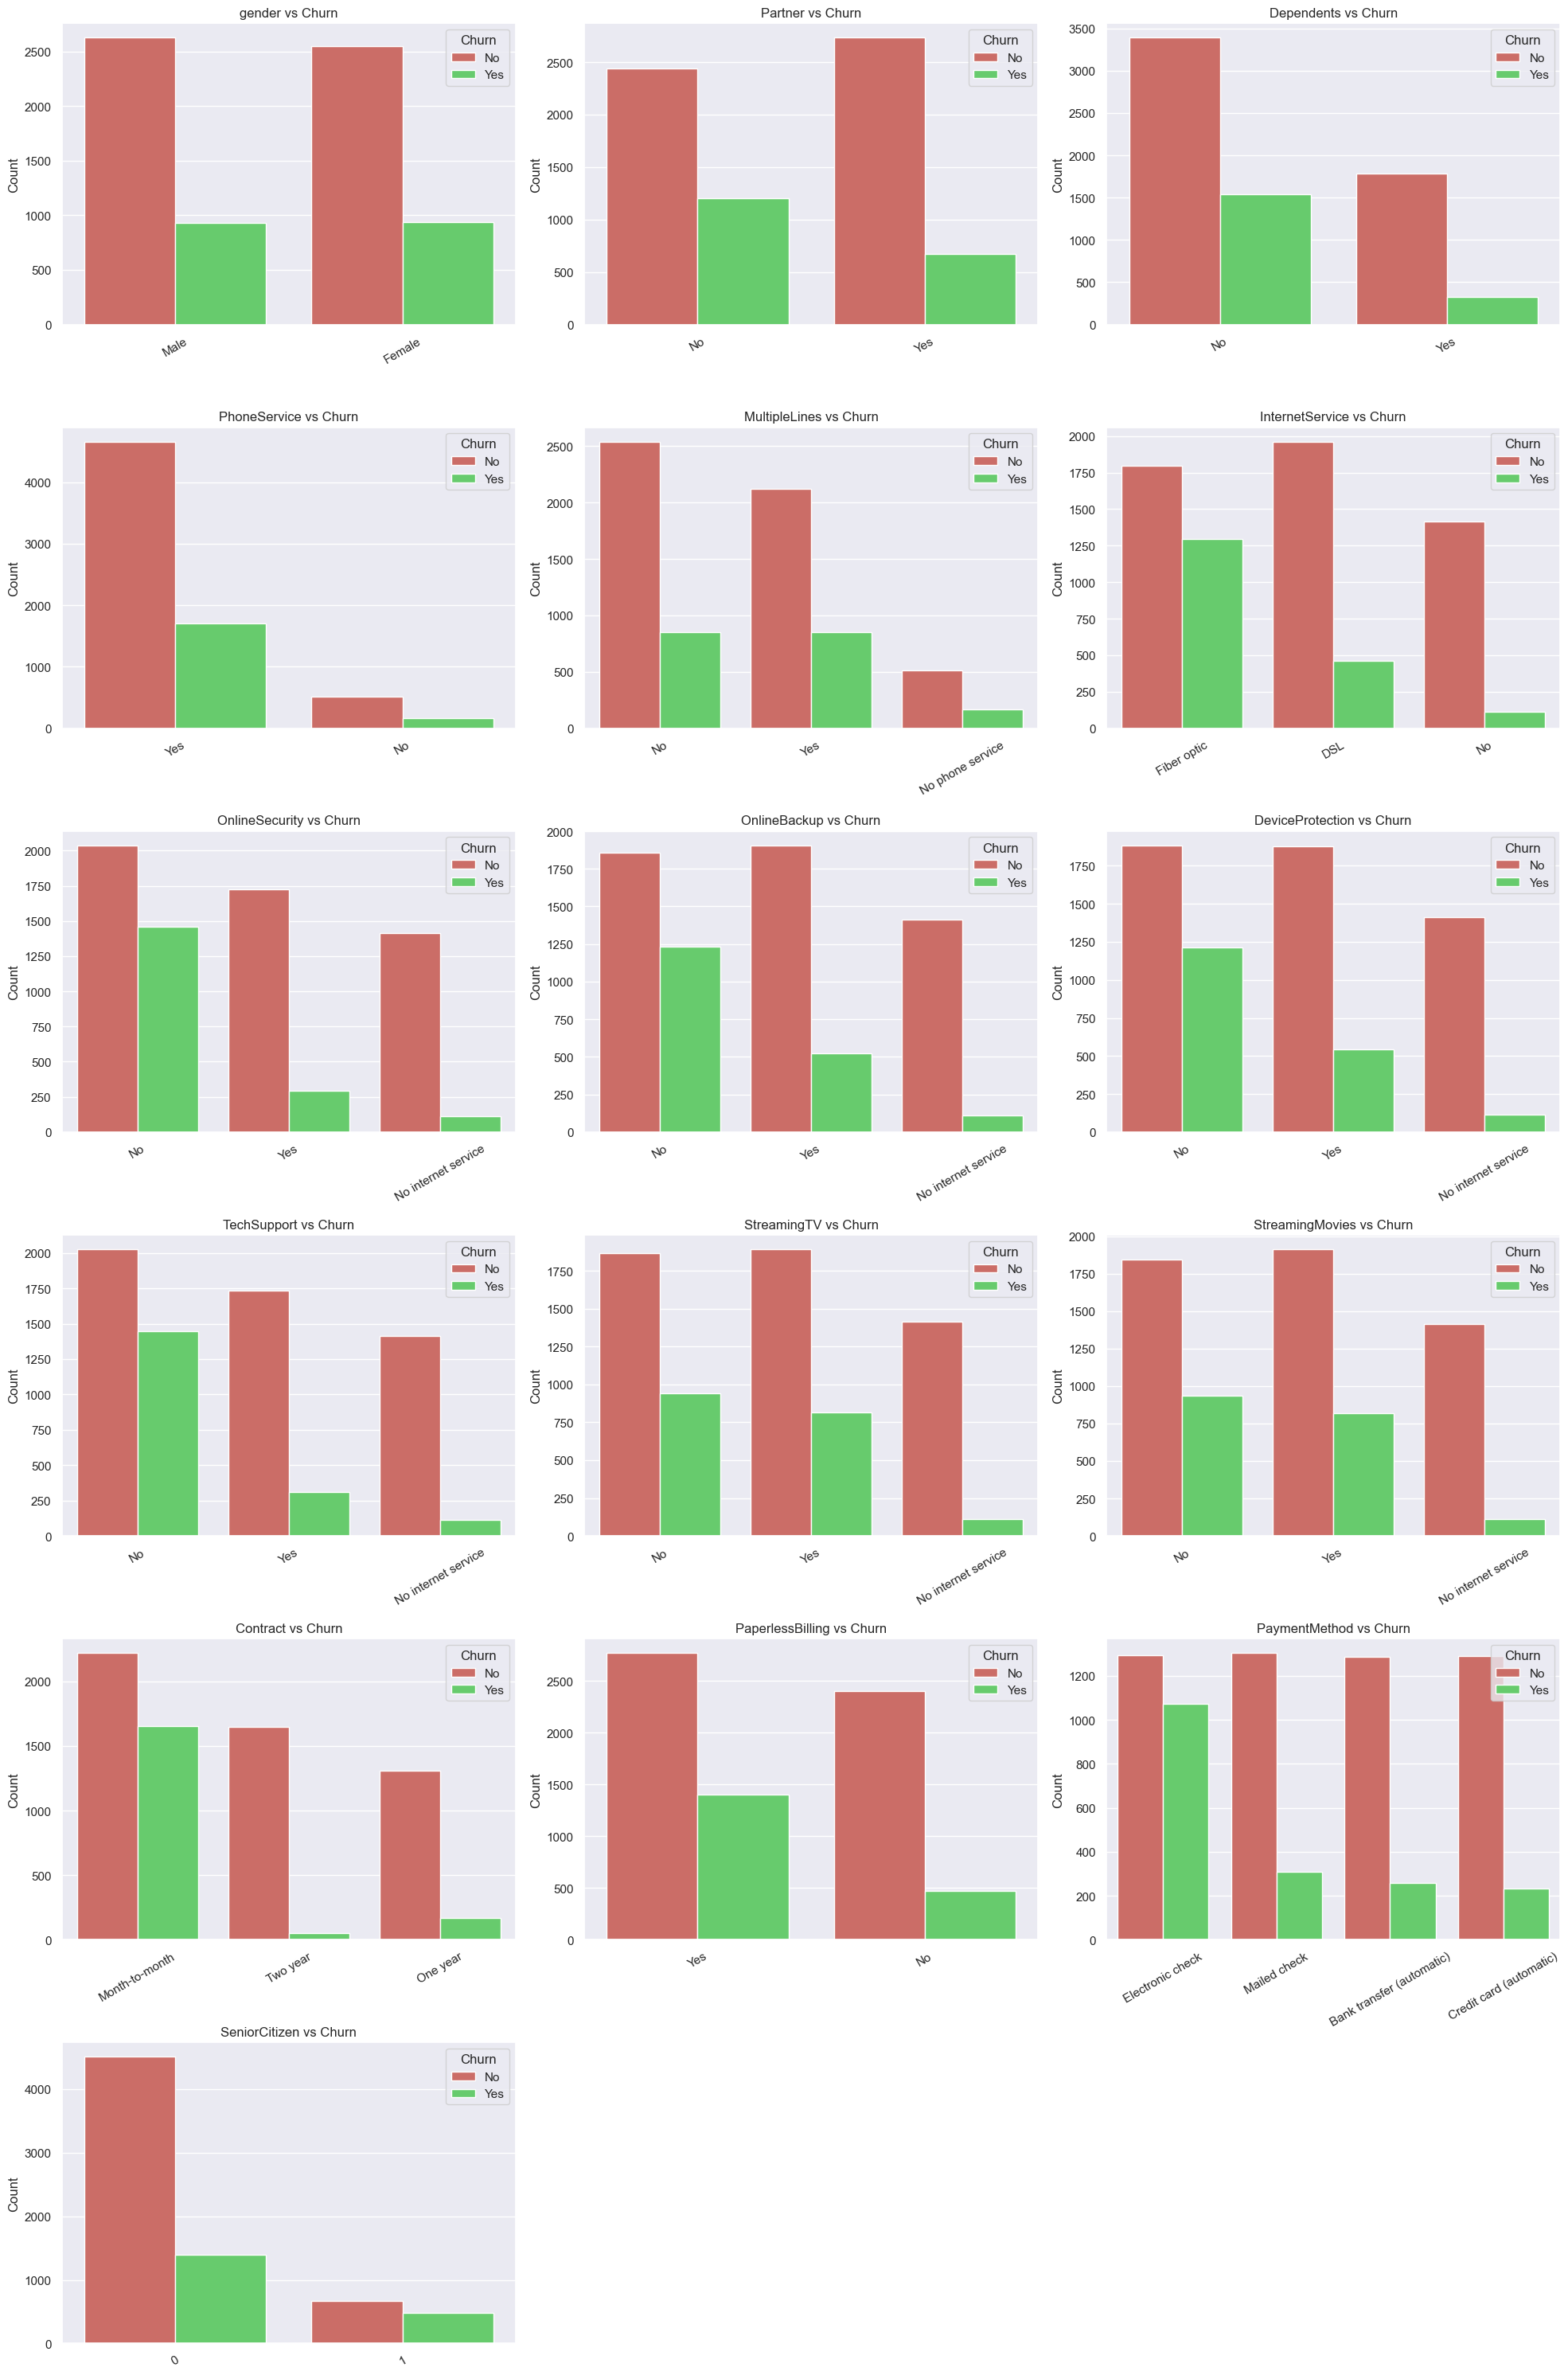

In [389]:
import math
import matplotlib.pyplot as plt
import seaborn as sns

n_cols = 3
n_rows = math.ceil(len(categorical_features) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(categorical_features):
    sns.countplot(
        data=df,
        x=col,
        hue="Churn",
        ax=axes[i],
        order=df[col].value_counts().index
    )
    
    axes[i].set_title(f"{col} vs Churn")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis="x", rotation=30)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

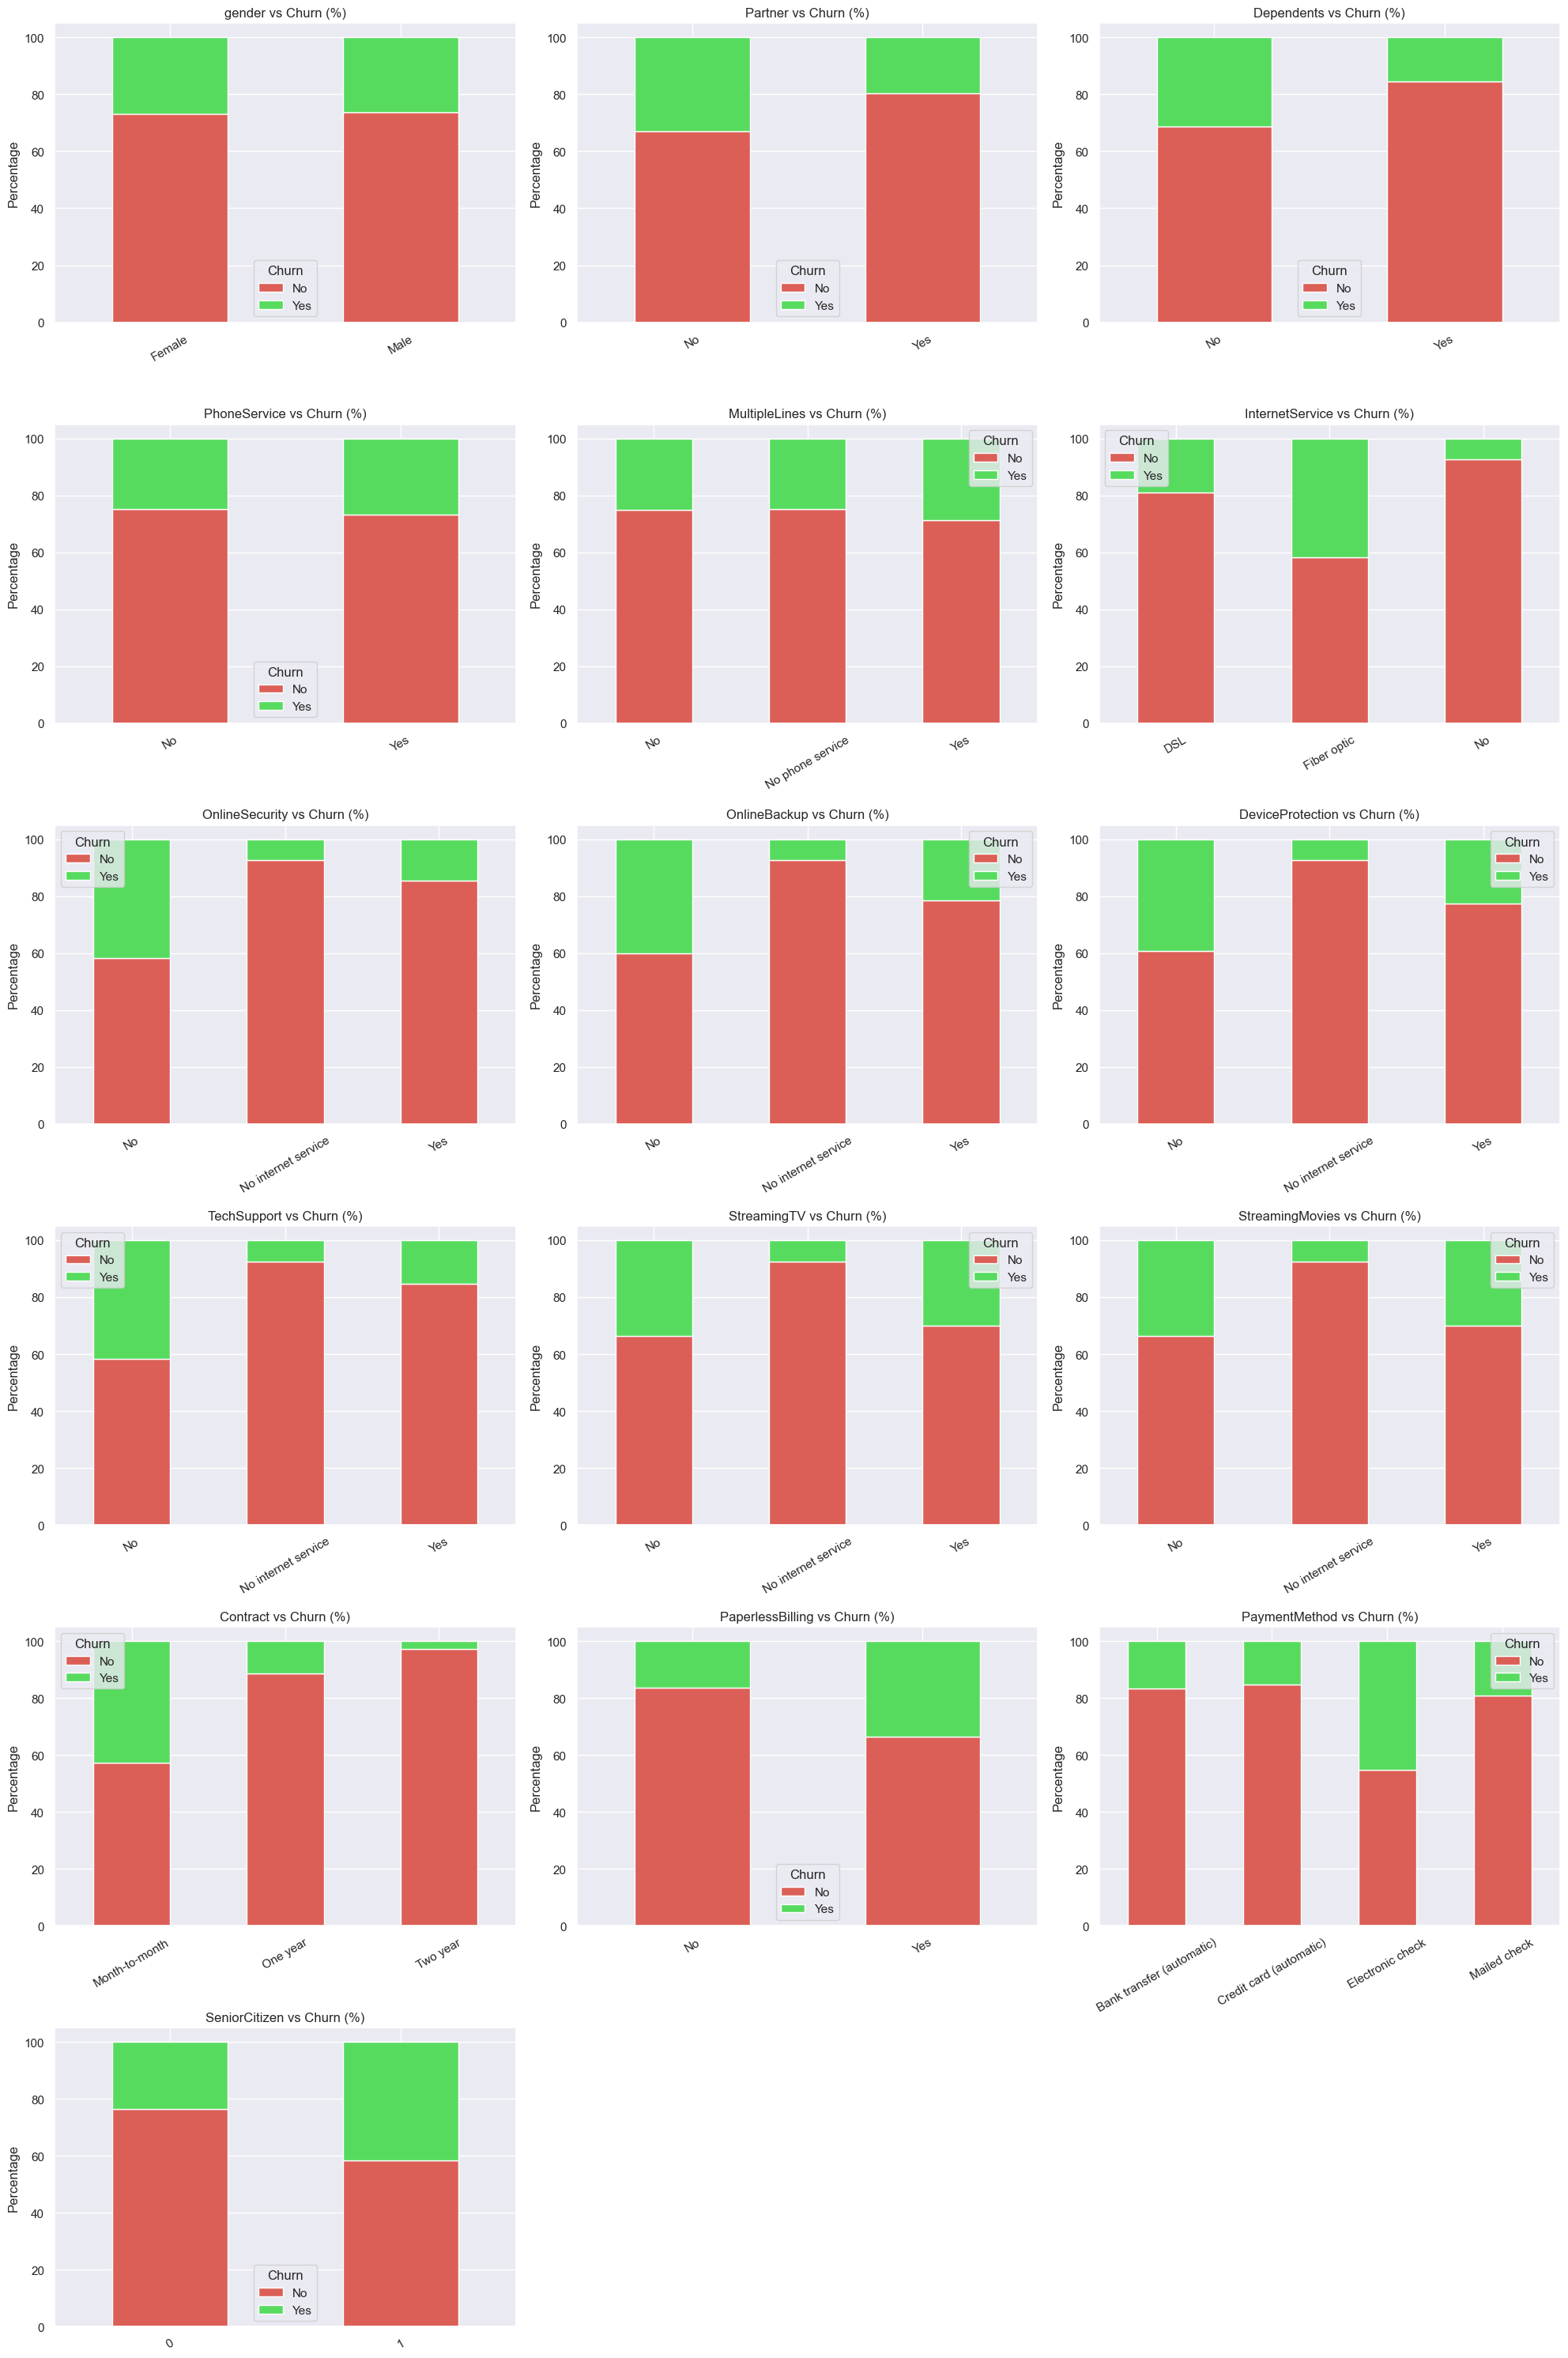

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

n_cols = 3
n_rows = math.ceil(len(categorical_features) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(categorical_features):

    churn_rate = pd.crosstab(
        df[col],
        df["Churn"],
        normalize="index"
    ) * 100

    churn_rate.plot(
        kind="bar",
        stacked=True,
        ax=axes[i]
    )

    axes[i].set_title(f"{col} vs Churn (%)")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Percentage")
    axes[i].tick_params(axis="x", rotation=30)
    axes[i].legend(title="Churn")

# Hide extra axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

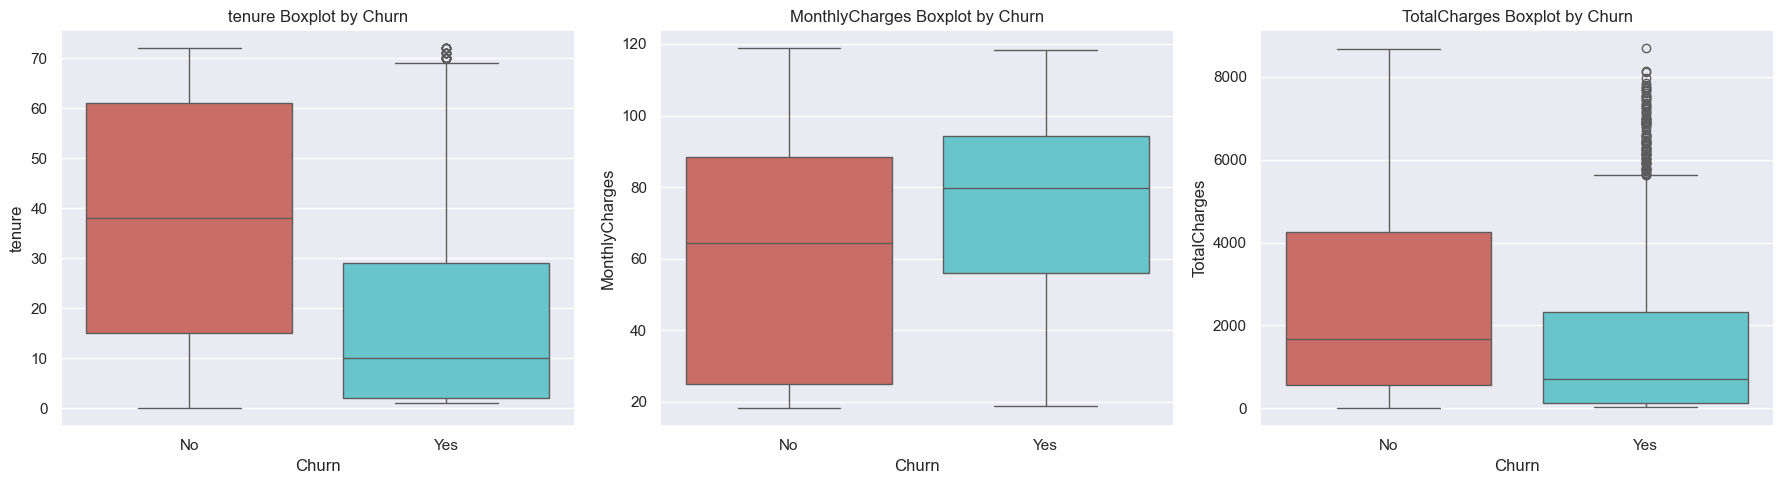

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, col in enumerate(numeric_cols):
    sns.boxplot(data=df, x='Churn', y=col, palette="hls", ax=axes[idx])
    axes[idx].set_title(f"{col} Boxplot by Churn")
plt.tight_layout()
plt.show()

In [ ]:
df[
    (df["Churn"] == "Yes") &
    (df["TotalCharges"] > 5500)
][["tenure", "MonthlyCharges",
   "TotalCharges"
   ]].head(20)

,tenure,MonthlyCharges
104,68,110.00
276,52,105.05
339,63,103.40
402,69,99.45
445,60,105.90
573,56,100.30
609,65,105.25
635,65,105.50
638,56,104.55
799,62,96.75


In [393]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [394]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (5634, 19)
X_test: (1409, 19)
y_train: (5634,)
y_test: (1409,)


In [395]:
print("Train target count:")
print(y_train.value_counts())

print("\nTrain target ratio:")
print(y_train.value_counts(normalize=True))

print("\nTest target count:")
print(y_test.value_counts())

print("\nTest target ratio:")
print(y_test.value_counts(normalize=True))

Train target count:
Churn
No     4139
Yes    1495
Name: count, dtype: int64

Train target ratio:
Churn
No     0.734647
Yes    0.265353
Name: proportion, dtype: float64

Test target count:
Churn
No     1035
Yes     374
Name: count, dtype: int64

Test target ratio:
Churn
No     0.734564
Yes    0.265436
Name: proportion, dtype: float64


In [396]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("continuous", StandardScaler(), continuous_features)
    ]
)

In [397]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
         )
    ]
)

model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod',
                                                   'SeniorCitizen']),
                                                 ('continuous',
                                                  StandardScaler(),
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [398]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod',
                                                   'SeniorCitizen']),
                                                 ('continuous',
                                                  StandardScaler(),
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [ ]:
# Encoded feature names
feature_names = model.named_steps["preprocessor"].get_feature_names_out()

print("Total Features:", len(feature_names))


Total Features: 46


In [402]:
y_pred = model.predict(X_test)


In [404]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.7381121362668559

Confusion Matrix:
[[747 288]
 [ 81 293]]

Classification Report:
              precision    recall  f1-score   support

          No       0.90      0.72      0.80      1035
         Yes       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



In [405]:
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_test)[:,1]

roc_auc_score(y_test.map({"No":0,"Yes":1}), y_prob)

0.841501976284585

In [406]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

In [407]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=100,
                max_depth=8,
                random_state=42,
                
            )
        )
    ]
)

rf_model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod',
                                                   'SeniorCitizen']),
                                                 ('continuous',
                                                  StandardScaler(),
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges'])])),
                ('classifier',
                 RandomForestClassifier(max_depth=8, random_state=42))])

In [408]:
rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod',
                                                   'SeniorCitizen']),
                                                 ('continuous',
                                                  StandardScaler(),
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges'])])),
                ('classifier',
                 RandomForestClassifier(max_depth=8, random_state=42))])

In [409]:
rf_y_pred = rf_model.predict(X_test)
rf_y_prob = rf_model.predict_proba(X_test)[:, 1]

In [410]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

print("Accuracy:", accuracy_score(y_test, rf_y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_y_pred))

print("\nClassification Report:")
print(classification_report(y_test, rf_y_pred))

print("ROC-AUC:", roc_auc_score(
    y_test.map({"No": 0, "Yes": 1}),
    rf_y_prob
))

Accuracy: 0.8034066713981547

Confusion Matrix:
[[941  94]
 [183 191]]

Classification Report:
              precision    recall  f1-score   support

          No       0.84      0.91      0.87      1035
         Yes       0.67      0.51      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409

ROC-AUC: 0.840334289183394


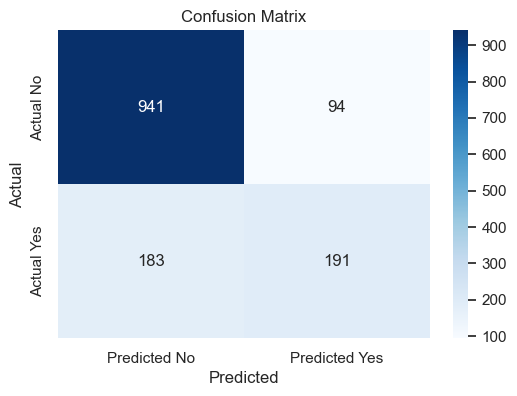

In [411]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, rf_y_pred, labels=["No", "Yes"])

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted No", "Predicted Yes"],
    yticklabels=["Actual No", "Actual Yes"]
)

plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

ROC-AUC: 0.840334289183394


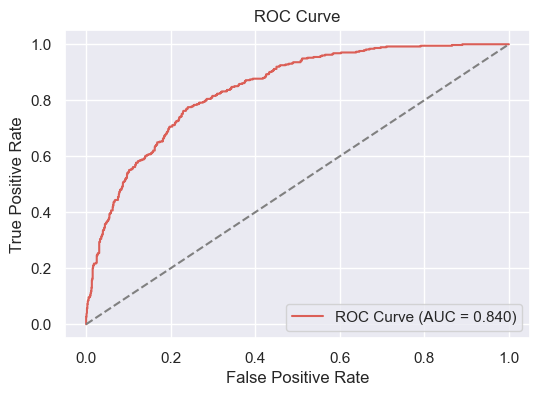

In [412]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

y_proba = rf_model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_proba)
print("ROC-AUC:", auc)

fpr, tpr, thresholds = roc_curve(y_test, y_proba, pos_label="Yes")

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [413]:
results = X_test.copy()
results["Actual"] = y_test
results["Predicted"] = rf_y_pred
results["Correct"] = results["Actual"] == results["Predicted"]

wrong_predictions = results[results["Correct"] == False]

print(wrong_predictions.shape)
wrong_predictions.head(30)

(277, 22)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Actual,Predicted,Correct
2280,Female,1,No,No,8,Yes,Yes,Fiber optic,No,No,...,Yes,Yes,Month-to-month,Yes,Credit card (automatic),100.15,908.55,No,Yes,False
1639,Male,1,No,No,17,Yes,No,DSL,No,No,...,No,No,Month-to-month,Yes,Electronic check,45.05,770.60,Yes,No,False
2136,Male,0,No,Yes,15,Yes,Yes,Fiber optic,No,Yes,...,Yes,No,Month-to-month,Yes,Electronic check,91.00,1430.05,No,Yes,False
761,Female,0,No,No,22,Yes,No,Fiber optic,No,No,...,Yes,Yes,Month-to-month,No,Electronic check,89.25,1907.85,Yes,No,False
2488,Male,0,No,No,31,Yes,No,DSL,No,No,...,No,No,Month-to-month,Yes,Electronic check,55.25,1715.65,Yes,No,False
2519,Male,0,Yes,No,2,Yes,Yes,Fiber optic,No,No,...,Yes,No,Month-to-month,Yes,Electronic check,91.45,171.45,No,Yes,False
3510,Female,0,No,No,8,Yes,Yes,Fiber optic,No,No,...,No,No,Month-to-month,Yes,Electronic check,75.25,576.70,No,Yes,False
523,Female,0,No,No,23,Yes,Yes,Fiber optic,No,No,...,No,No,Month-to-month,No,Bank transfer (automatic),75.60,1758.60,Yes,No,False
5086,Male,0,No,No,45,Yes,No,No,No internet service,No internet service,...,No internet service,No internet service,One year,Yes,Electronic check,20.40,930.45,Yes,No,False
3408,Female,0,No,No,4,Yes,No,DSL,No,Yes,...,No,No,Month-to-month,No,Credit card (automatic),50.70,151.30,Yes,No,False


In [414]:
false_negative = results[
    (results["Actual"]=="Yes") &
    (results["Predicted"]=="No")
]

false_positive = results[
    (results["Actual"]=="No") &
    (results["Predicted"]=="Yes")
]

print("False Negatives:", false_negative.shape)

print("False Positives:", false_positive.shape)

False Negatives: (183, 22)
False Positives: (94, 22)


In [415]:
false_negative.describe(include="all")

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Actual,Predicted,Correct
count,183,183.000000,183,183,183.000000,183,183,183,183,183,...,183,183,183,183,183,183.000000,183.000000,183,183,183
unique,2,NaN,2,2,NaN,2,3,3,3,3,...,3,3,3,2,4,NaN,NaN,1,1,1
top,Female,NaN,No,No,NaN,Yes,No,Fiber optic,No,No,...,No,No,Month-to-month,Yes,Electronic check,NaN,NaN,Yes,No,False
freq,97,NaN,105,130,NaN,163,87,93,106,91,...,85,80,138,118,66,NaN,NaN,183,183,183
mean,NaN,0.224044,NaN,NaN,25.825137,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,68.631148,2182.749180,NaN,NaN,NaN
std,NaN,0.418095,NaN,NaN,20.915109,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,29.057975,2151.524616,NaN,NaN,NaN
min,NaN,0.000000,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,18.950000,19.300000,NaN,NaN,NaN
25%,NaN,0.000000,NaN,NaN,7.000000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,49.050000,241.250000,NaN,NaN,NaN
50%,NaN,0.000000,NaN,NaN,22.000000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,73.750000,1561.500000,NaN,NaN,NaN
75%,NaN,0.000000,NaN,NaN,40.500000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,93.950000,3194.125000,NaN,NaN,NaN


In [416]:
false_positive.describe(include="all")

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Actual,Predicted,Correct
count,94,94.000000,94,94,94.000000,94,94,94,94,94,...,94,94,94,94,94,94.000000,94.000000,94,94,94
unique,2,NaN,2,2,NaN,2,3,2,2,2,...,2,2,1,2,4,NaN,NaN,1,1,1
top,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,No,...,No,No,Month-to-month,Yes,Electronic check,NaN,NaN,No,Yes,False
freq,53,NaN,74,82,NaN,90,46,78,88,74,...,60,59,94,76,65,NaN,NaN,94,94,94
mean,NaN,0.297872,NaN,NaN,9.382979,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,77.243085,822.449468,NaN,NaN,NaN
std,NaN,0.459775,NaN,NaN,10.193933,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,17.921562,1036.790125,NaN,NaN,NaN
min,NaN,0.000000,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,24.900000,25.350000,NaN,NaN,NaN
25%,NaN,0.000000,NaN,NaN,3.000000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,70.312500,187.100000,NaN,NaN,NaN
50%,NaN,0.000000,NaN,NaN,6.000000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,78.525000,478.950000,NaN,NaN,NaN
75%,NaN,1.000000,NaN,NaN,11.000000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,90.437500,994.837500,NaN,NaN,NaN


In [417]:
import pandas as pd

feature_names = rf_model.named_steps["preprocessor"].get_feature_names_out()

importances = rf_model.named_steps["classifier"].feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(20)

,Feature,Importance
43,continuous__tenure,0.134701
45,continuous__TotalCharges,0.121438
32,categorical__Contract_Month-to-month,0.113121
44,continuous__MonthlyCharges,0.065866
12,categorical__InternetService_Fiber optic,0.060472
23,categorical__TechSupport_No,0.057955
14,categorical__OnlineSecurity_No,0.055532
39,categorical__PaymentMethod_Electronic check,0.045050
34,categorical__Contract_Two year,0.037673
17,categorical__OnlineBackup_No,0.028124


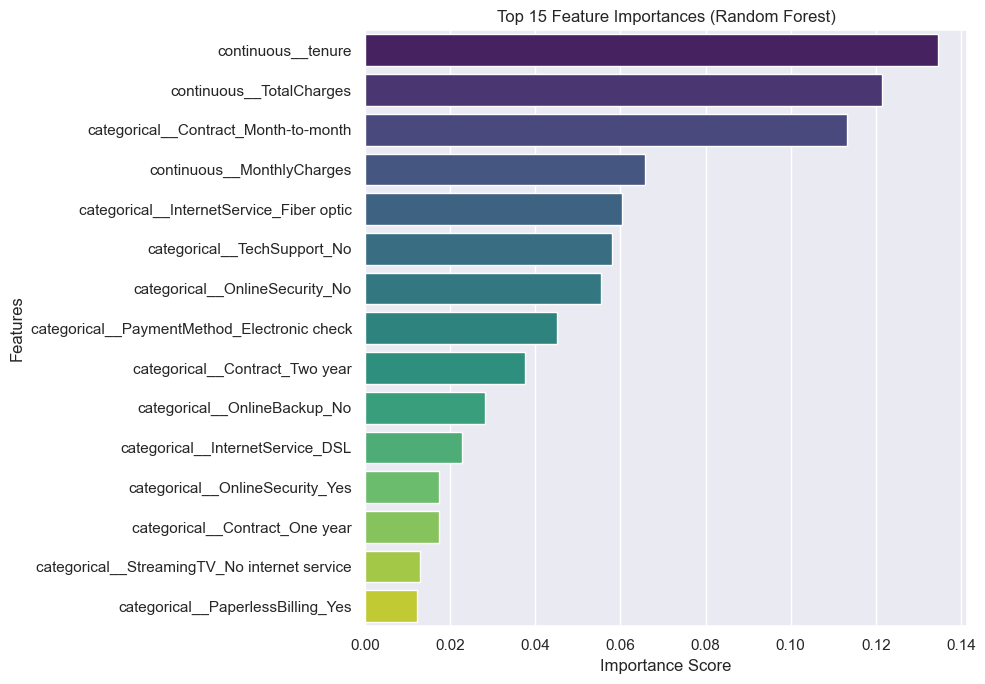

In [420]:


plt.figure(figsize=(10,7))

sns.barplot(
    data=feature_importance.head(15),
    x="Importance",
    y="Feature",
    palette="viridis"
)

plt.title("Top 15 Feature Importances (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.tight_layout()
plt.show()

In [421]:
import numpy as np
import pandas as pd

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

threshold_results = []

for threshold in np.arange(0.25, 0.76, 0.05):
    try:
        y_proba = rf_model.predict_proba(X_test)[:, 1]
    except NameError:
        y_proba = model.predict_proba(X_test)[:, 1]

    y_pred_threshold = np.where(y_proba >= threshold, "Yes", "No")
    
    threshold_results.append({
        "threshold": round(threshold, 2),
        "accuracy": accuracy_score(y_test, y_pred_threshold),
        "precision_yes": precision_score(y_test, y_pred_threshold, pos_label="Yes"),
        "recall_yes": recall_score(y_test, y_pred_threshold, pos_label="Yes"),
        "f1_yes": f1_score(y_test, y_pred_threshold, pos_label="Yes")
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df

,threshold,accuracy,precision_yes,recall_yes,f1_yes
0,0.25,0.731725,0.496711,0.807487,0.615071
1,0.30,0.758694,0.531136,0.775401,0.630435
2,0.35,0.770759,0.552361,0.719251,0.624855
3,0.40,0.782825,0.581731,0.647059,0.612658
4,0.45,0.794890,0.620397,0.585561,0.602476
5,0.50,0.803407,0.670175,0.510695,0.579666
6,0.55,0.798439,0.710280,0.406417,0.517007
7,0.60,0.793471,0.745562,0.336898,0.464088
8,0.65,0.779276,0.748031,0.254011,0.379242
9,0.70,0.772889,0.813953,0.187166,0.304348
